# Import i konfiguracja

In [177]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Konfiguracja wizualna
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings("ignore")


# Pobieranie i Wczytanie Danych

In [156]:
# Pobieranie datasetu
path = kagglehub.dataset_download('brycecf/give-me-some-credit-dataset')
print("Path to dataset files:", path)

# Znalezienie pliku CSV
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_file:
    df_raw = pd.read_csv(os.path.join(path, csv_file[1]))
    print(f'Wczystano plik: {csv_file[1]}')
    print(f'Rozmiar datasetu: {df_raw.shape}')
else:
    raise FileNotFoundError('Nie znaleziono pliku CSV w pobranych danych.')

# Kopia robocza
df = df_raw.copy()
df.head()   

Path to dataset files: C:\Users\konta\.cache\kagglehub\datasets\brycecf\give-me-some-credit-dataset\versions\1
Wczystano plik: cs-training.csv
Rozmiar datasetu: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


# Czyszczenie Danych (Data Cleaning)

In [157]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [158]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,75000.50,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,43301.41,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37500.75,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,75000.50,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112500.25,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,150000.00,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [159]:
stats_list = []
for c in df.columns:
    stats_list.append({
        'Feature': c,
        'Min': df[c].min(),
        'Quantile_0.001': df[c].quantile(0.001),
        'Max': df[c].max(),
        'Quantile_0.999': df[c].quantile(0.999)
    })
stats_df = pd.DataFrame(stats_list)
print(stats_df)

                                 Feature  Min  Quantile_0.001        Max  Quantile_0.999
0                             Unnamed: 0 1.00          151.00  150000.00       149850.00
1                       SeriousDlqin2yrs 0.00            0.00       1.00            1.00
2   RevolvingUtilizationOfUnsecuredLines 0.00            0.00   50708.00         1571.01
3                                    age 0.00           21.00     109.00           94.00
4   NumberOfTime30-59DaysPastDueNotWorse 0.00            0.00      98.00           98.00
5                              DebtRatio 0.00            0.00  329664.00        10613.07
6                          MonthlyIncome 0.00            0.00 3008750.00        78395.75
7        NumberOfOpenCreditLinesAndLoans 0.00            0.00      58.00           34.00
8                NumberOfTimes90DaysLate 0.00            0.00      98.00           98.00
9           NumberRealEstateLoansOrLines 0.00            0.00      54.00            9.00
10  NumberOfTime60-89

In [160]:
df = df[df['age'] >= 18]

In [161]:
print(df['RevolvingUtilizationOfUnsecuredLines'].describe())
high_utilization = df[df['RevolvingUtilizationOfUnsecuredLines'] > 1]
print(f"\nLiczba wierszy z utilization > 1: {len(high_utilization)}")

absurd_utilization = df[df['RevolvingUtilizationOfUnsecuredLines'] > 10]
print(f"Liczba wierszy z utilization > 10: {len(absurd_utilization)}")

default_rate_normal = df[df['RevolvingUtilizationOfUnsecuredLines'] <= 1]['SeriousDlqin2yrs'].mean()
default_rate_high = high_utilization['SeriousDlqin2yrs'].mean()

print(f"\nŚredni Default Rate dla <= 1: {default_rate_normal:.2%}")
print(f"Średni Default Rate dla > 1:  {default_rate_high:.2%}")

count   149999.00
mean         6.05
std        249.76
min          0.00
25%          0.03
50%          0.15
75%          0.56
max      50708.00
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

Liczba wierszy z utilization > 1: 3321
Liczba wierszy z utilization > 10: 241

Średni Default Rate dla <= 1: 5.99%
Średni Default Rate dla > 1:  37.25%


In [162]:
q999 = df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.999)
print(f"99.9-ty centyl wynosi: {q99}")
upper_limit = 15

df2 = df.copy()
df2.loc[df['RevolvingUtilizationOfUnsecuredLines'] > upper_limit, 'RevolvingUtilizationOfUnsecuredLines'] = upper_limit
print("\nNaprawiono. Nowe maksimum:", df2['RevolvingUtilizationOfUnsecuredLines'].max())

99.9-ty centyl wynosi: 1571.0060000001104

Naprawiono. Nowe maksimum: 15.0


In [163]:
# Sprawdzamy, ile procent danych brakuje w każdej kolumnie
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Braki (Liczba)': missing_data, 
    'Braki (%)': missing_percent
})

# Pokaż tylko te kolumny, gdzie są braki (> 0)
print(missing_table[missing_table['Braki (Liczba)'] > 0].sort_values(by='Braki (%)', ascending=False))

                    Braki (Liczba)  Braki (%)
MonthlyIncome                29731      19.82
NumberOfDependents            3924       2.62


In [164]:
if 'Unnamed: 0' in df.columns:
    df2.drop('Unnamed: 0', axis=1, inplace=True)
    print("Usunięto kolumnę 'Unnamed: 0'.")

Usunięto kolumnę 'Unnamed: 0'.


In [165]:
# --- NAPRAWA BŁĘDÓW 96/98 ---
# Kolumny z opóźnieniami
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 
             'NumberOfTime60-89DaysPastDueNotWorse', 
             'NumberOfTimes90DaysLate']

# Sprawdźmy ile tego jest
print("Liczba wystąpień 96/98 przed naprawą:")
for col in late_cols:
    print(f"{col}: {df2[df2[col].isin([96, 98])].shape[0]}")

# Zamieniamy 96 i 98 na NaN (traktujemy jako brak danych)
for col in late_cols:
    df2[col] = df2[col].replace([96, 98], np.nan)

Liczba wystąpień 96/98 przed naprawą:
NumberOfTime30-59DaysPastDueNotWorse: 269
NumberOfTime60-89DaysPastDueNotWorse: 269
NumberOfTimes90DaysLate: 269


### KNN Imputer

In [166]:
# Wybór kolumn do modelu KNN dla cechy MonthlyIncome
knn_cols = ['age', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'DebtRatio', 'MonthlyIncome','NumberOfDependents']

df_knn = df2[knn_cols].copy()

#Skalowanie danych
scaler = StandardScaler()
df_knn_scaled = pd.DataFrame(scaler.fit_transform(df_knn), columns=knn_cols)

imputer = KNNImputer(n_neighbors=5)
df_knn_filled_scaled = imputer.fit_transform(df_knn_scaled)


In [167]:
df_knn_filled = scaler.inverse_transform(df_knn_filled_scaled)
df_knn_filled = pd.DataFrame(df_knn_filled, columns=knn_cols)

df3_knn = df2.copy()
df3_knn['MonthlyIncome'] = df_knn_filled['MonthlyIncome']
df3_knn['NumberOfDependents'] = df_knn_filled['NumberOfDependents'].round()

df3_knn['MonthlyIncome'].isnull().sum()
df3_knn['NumberOfDependents'].isnull().sum()

np.int64(1)

### Iterative Imputer

In [168]:
df_interactive = df2.copy()

features_to_impute = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 
    'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 
    'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 
    'NumberOfDependents'
]

df_input = df_interactive[features_to_impute]

# Konfiguracja imputacji
# min_value=0 -> Zabezpieczenie przed ujemnym dochodem/dziećmi
imputer = IterativeImputer(max_iter=10, random_state=42, min_value=0)

# Imputacja danych
df_imputed_array = imputer.fit_transform(df_input)

# Konwersja z powrotem na DataFrame
df_imputed = pd.DataFrame(df_imputed_array, columns=features_to_impute)

# Liczba osób na utrzymaniu musi być całkowita
df_imputed['NumberOfDependents'] = df_imputed['NumberOfDependents'].round()

# Podmiana w głównym zbiorze danych
df3_ii = df2.copy()
df3_ii[features_to_impute] = df_imputed


### Wybór modelu do predykcji 

In [169]:
# Wybór metody KNN lub II

#df4 = df3_ii.copy()
df4 = df3_knn.copy()

### Feature Engineering

In [170]:
df4.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.77,45,2.00,0.80,9120.00,13,0.00,6,0.00,2.00
1,0,0.96,40,0.00,0.12,2600.00,4,0.00,0,0.00,1.00
2,0,0.66,38,1.00,0.09,3042.00,2,1.00,0,0.00,0.00
3,0,0.23,30,0.00,0.04,3300.00,5,0.00,0,0.00,0.00
4,0,0.91,49,1.00,0.02,63588.00,7,0.00,1,0.00,0.00


In [171]:
# Dodajemy cechę, która mówi o ogólnej rzetelności klienta
df4['TotalPastDue'] = (df4['NumberOfTime30-59DaysPastDueNotWorse'] + df4['NumberOfTime60-89DaysPastDueNotWorse'] + df4['NumberOfTimes90DaysLate'])

# Dodajemy cechę, dochód na osobę w rodzinie
df4['IncomePerPerson'] = df4['MonthlyIncome'] / (df4['NumberOfDependents']+1)

# Dodajemy cechę ile goówki zostaje klientowi po opłacenie kredytu
df4['MonthlyBalance'] = df4['MonthlyIncome'] - (df4['MonthlyIncome'] * df4['DebtRatio'])

In [172]:
# Skalowanie

X = df4.drop('SeriousDlqin2yrs', axis=1)
y = df4['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns )
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)


### XGBoost

In [173]:
# Obliczamy wagę dla niezbalansowanych danych
ratio = float(np.sum(y_train==0)) / np.sum(y_train==1)
print(f'Obliczony scale_pos_weight: {ratio:.2f}')

# Konfiguracja XGBoost
model_xgb = XGBClassifier(n_estimators=100,
                        learning_rate=0.1,
                        max_depth=5,
                        scale_pos_weight=ratio,
                        use_label_encoder=False,
                        eval_metric='logloss',
                        random_state=42)

# Trenowanie modelu 
model_xgb.fit(X_train_scaled, y_train) 

# Predykcja
y_pred = model_xgb.predict(X_test_scaled)
y_proba = model_xgb.predict_proba(X_test_scaled)[:, 1]

# Ewaluacja
roc_score = roc_auc_score(y_test, y_proba)

print(f"\n--- WYNIKI XGBOOST ---")
print(f"ROC-AUC Score: {roc_score:.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred))

Obliczony scale_pos_weight: 13.96

--- WYNIKI XGBOOST ---
ROC-AUC Score: 0.8684
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.22      0.77      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.85     30000



<Figure size 1000x800 with 0 Axes>

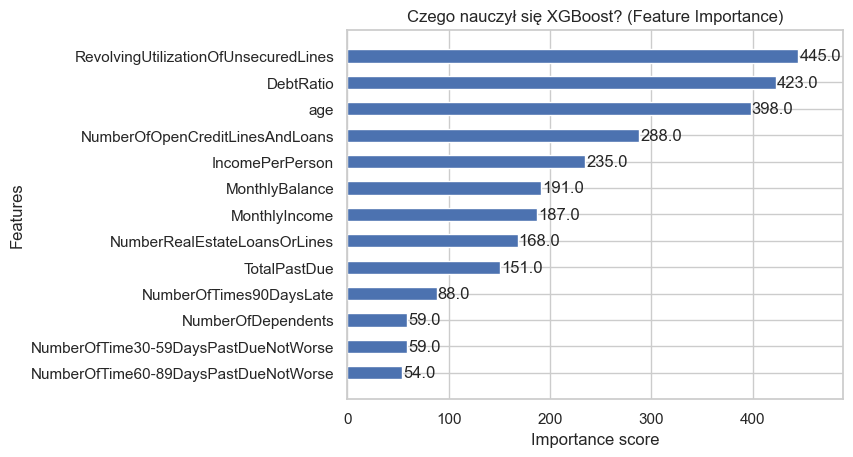

In [174]:
from xgboost import plot_importance

# Wyświetlamy ranking cech
plt.figure(figsize=(10, 8))
plot_importance(model_xgb, max_num_features=15, height=0.5)
plt.title("Czego nauczył się XGBoost? (Feature Importance)")
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

# Inicjalizacja JS (potrzebne do wizualizacji w notebooku)
shap.initjs()

# 1. Tworzy wyjaśniacz (Explainer) dla modelu XGBoost
explainer = shap.TreeExplainer(model_xgb)

# 2. Obliczamy wartości SHAP dla zbioru testowego
# (Może chwilę potrwać, jeśli masz wolny komputer - wtedy weź np. X_test_scaled.iloc[:1000])
shap_values = explainer.shap_values(X_test_scaled)

print("Wartości SHAP obliczone.")

Wartości SHAP obliczone.


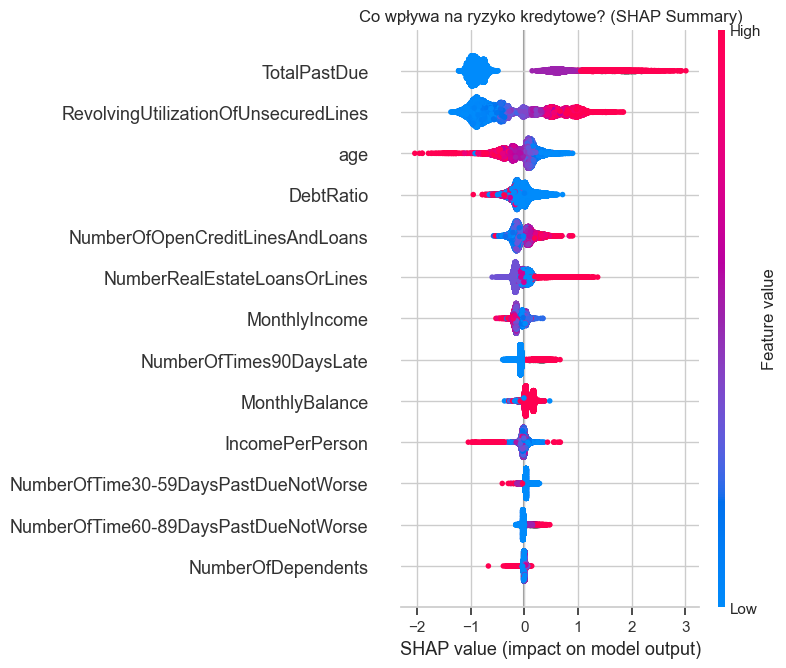

In [179]:
# Rysujemy wykres podsumowujący (Summary Plot)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title("Co wpływa na ryzyko kredytowe? (SHAP Summary)")
plt.show()